# BAAC - Classification 

## Import et chargement

In [86]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [39]:
df = pd.read_csv('../data/processed/baac_final.csv')

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 479684 entries, 0 to 479683
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   grav      479684 non-null  int64  
 1   catu      479684 non-null  int64  
 2   sexe      479684 non-null  float64
 3   lum       479684 non-null  float64
 4   agg       479684 non-null  int64  
 5   atm       479684 non-null  float64
 6   surf      479684 non-null  float64
 7   catv_grp  479684 non-null  str    
 8   issecu    479684 non-null  bool   
 9   age_grp   479684 non-null  str    
 10  vma_grp   479684 non-null  str    
dtypes: bool(1), float64(4), int64(3), str(3)
memory usage: 37.1 MB


## Train-Test Split

In [41]:
X = df.drop(columns='grav')
y = df['grav']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=222
)

## Encodages

In [43]:
cat_features = ['catu','sexe','lum','agg','atm','surf','catv_grp','age_grp','vma_grp']

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_features
        )
    ],
    remainder='passthrough'
)

## Baseline

In [45]:
baseline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

In [46]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['catu','sexe','lum',...,'issecu','age_grp','vma_grp']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not 

In [47]:
y_pred_baseline = baseline.predict(X_test)

In [48]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     78712
           1       0.00      0.00      0.00     17225

    accuracy                           0.82     95937
   macro avg       0.41      0.50      0.45     95937
weighted avg       0.67      0.82      0.74     95937



C:\Users\mnl77\miniconda3\envs\CLASSIF_BAAC\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mnl77\miniconda3\envs\CLASSIF_BAAC\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mnl77\miniconda3\envs\CLASSIF_BAAC\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## Regression Logistique

In [49]:
log_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(max_iter=1000))
    ])

In [50]:
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

In [51]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90     78712
           1       0.53      0.16      0.25     17225

    accuracy                           0.82     95937
   macro avg       0.69      0.56      0.57     95937
weighted avg       0.79      0.82      0.78     95937



In [52]:
cm = confusion_matrix(y_test, y_pred_log)
cm

array([[76312,  2400],
       [14479,  2746]])

<Axes: >

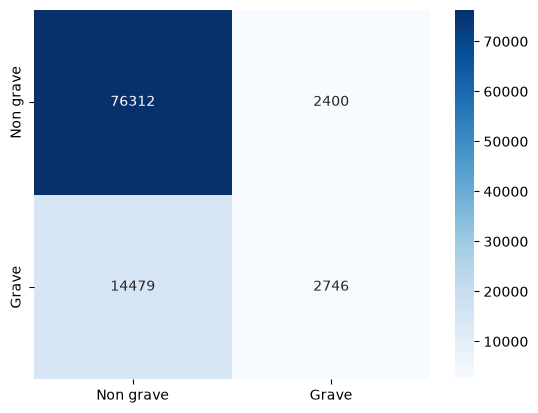

In [53]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation
La régression logistique obtient une accuracy de 82 %, mais présente un faible recall pour la classe grave (16 %). Le modèle identifie correctement la majorité des accidents non graves, mais manque une part importante des accidents graves, avec 14 479 faux négatifs.

### Réentrainer le modèle avec hyperparametre

In [55]:
log_model_b = Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression(class_weight='balanced',max_iter=1000))
    ])

In [56]:
log_model_b.fit(X_train, y_train)
y_pred_log_b = log_model_b.predict(X_test)

In [63]:
print(classification_report(y_test,y_pred_log_b))

              precision    recall  f1-score   support

           0       0.92      0.67      0.78     78712
           1       0.33      0.73      0.45     17225

    accuracy                           0.68     95937
   macro avg       0.62      0.70      0.62     95937
weighted avg       0.81      0.68      0.72     95937



In [62]:
cm = confusion_matrix(y_test,y_pred_log_b)
cm

array([[53119, 25593],
       [ 4704, 12521]])

<Axes: >

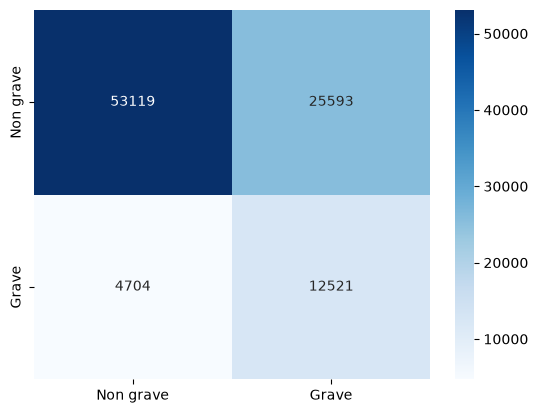

In [61]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation

L'utilisation de `class_weight='balanced'` améliore fortement la détection des accidents graves. Le recall de la classe 1 passe de 16 % à 73 %, tandis que le F1-score passe de 0,25 à 0,45. Le nombre de faux négatifs diminue également de 14 479 à 4 704.

En contrepartie, le modèle produit davantage de faux positifs (25 593) et l'accuracy globale diminue de 82 % à 68 %. Cette évolution montre que la pondération des classes favorise la détection des accidents graves, au prix d'une moins bonne identification des accidents non graves.


## Decision Tree

In [69]:
tree_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',DecisionTreeClassifier(random_state=222))
])

In [70]:
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [72]:
print(classification_report(y_test,y_pred_tree))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     78712
           1       0.53      0.22      0.31     17225

    accuracy                           0.83     95937
   macro avg       0.69      0.59      0.60     95937
weighted avg       0.79      0.83      0.79     95937



<Axes: >

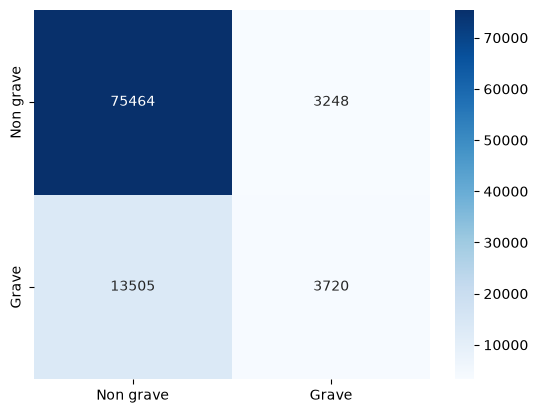

In [73]:
cm = confusion_matrix(y_test,y_pred_tree)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation

Le Decision Tree obtient une accuracy de 83 %, contre 82 % pour la régression logistique non équilibrée. Pour la classe 1, le recall passe de 16 % à 22 % et le F1-score de 0,25 à 0,31. Cette différence reste limitée : le modèle manque encore 13 505 accidents graves sur 17 225.

Le déséquilibre des classes reste donc un problème important pour la détection des accidents graves.

## Random Forest

In [76]:
forest_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',RandomForestClassifier(n_estimators=100,random_state=777,n_jobs=1))
     ])

In [78]:
forest_model.fit(X_train, y_train)
y_pred_forest = forest_model.predict(X_test)

In [79]:
print(classification_report(y_test,y_pred_forest))

              precision    recall  f1-score   support

           0       0.85      0.96      0.90     78712
           1       0.54      0.22      0.31     17225

    accuracy                           0.83     95937
   macro avg       0.70      0.59      0.61     95937
weighted avg       0.79      0.83      0.80     95937



<Axes: >

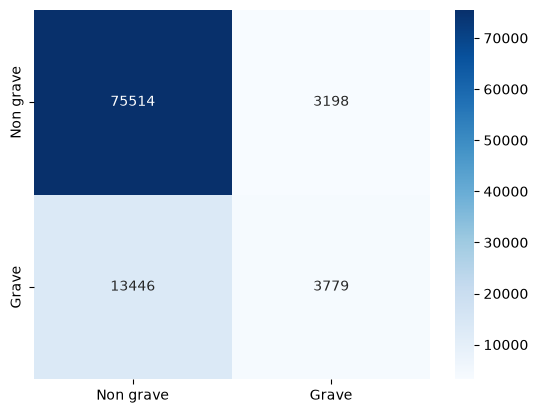

In [96]:
cm = confusion_matrix(y_test,y_pred_forest)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interpretation

Le Random Forest obtient une accuracy de 83 %, avec un recall de 22 % et un F1-score de 0,31 pour la classe 1. Ces résultats sont très proches de ceux obtenus avec le Decision Tree.

La matrice de confusion montre 13 446 faux négatifs et 3 779 vrais positifs. Le Random Forest ne permet donc pas, dans cette configuration, d'améliorer significativement la détection des accidents graves par rapport au Decision Tree.

## Gradient Boosting

In [87]:
gradb_model = Pipeline([
    ('preprocessor',preprocessor),
    ('model',GradientBoostingClassifier(n_estimators=100, random_state=111))
    ])

In [88]:
gradb_model.fit(X_train,y_train)
y_pred_gradb = gradb_model.predict(X_test)

In [90]:
print(classification_report(y_test,y_pred_gradb))

              precision    recall  f1-score   support

           0       0.85      0.97      0.90     78712
           1       0.58      0.19      0.29     17225

    accuracy                           0.83     95937
   macro avg       0.71      0.58      0.59     95937
weighted avg       0.80      0.83      0.79     95937



<Axes: >

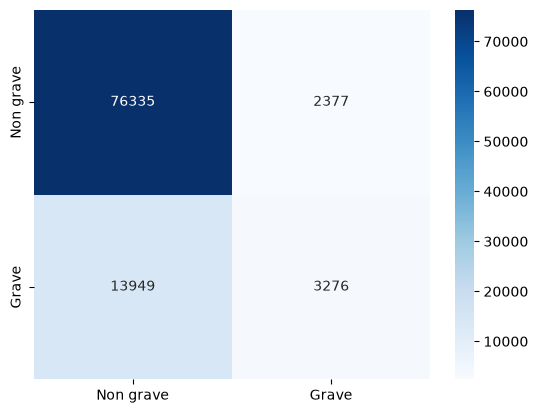

In [94]:
cm = confusion_matrix(y_test,y_pred_gradb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non grave', 'Grave'],
    yticklabels=['Non grave', 'Grave']
)

### Interprétation

Le Gradient Boosting obtient une accuracy de 83 %. Pour la classe 1, le recall est de 19 % et le F1-score de 0,29. Avec 13 949 faux négatifs, le modèle détecte une faible proportion des accidents graves.

Les performances sont proches de celles du Decision Tree et du Random Forest, sans amélioration notable de la détection de la classe grave dans cette configuration.